# 🤖 Visão Computacional: Uma Introdução

A **Visão Computacional (Computer Vision)** é um campo da Inteligência Artificial que permite aos computadores "ver", identificar e processar imagens e vídeos da mesma forma que os seres humanos. Ela busca automatizar tarefas que o sistema visual humano realiza.

## O Que é Visão Computacional?

Em sua essência, a Visão Computacional é a ciência que tenta fazer com que os computadores entendam o mundo visual. Isso envolve:
*   **Aquisição de Imagens:** Capturar dados visuais (fotos, vídeos).
*   **Processamento de Imagens:** Melhorar, filtrar e transformar os dados visuais.
*   **Análise de Imagens:** Extrair informações significativas desses dados.
*   **Tomada de Decisão:** Usar as informações extraídas para realizar uma tarefa ou fazer uma inferência.

## Aplicações Chave

A Visão Computacional está presente em muitas áreas do nosso dia a dia:
*   **Reconhecimento Facial:** Desbloqueio de celulares, segurança.
*   **Veículos Autônomos:** Detecção de pedestres, sinais de trânsito, outros veículos.
*   **Medicina:** Diagnóstico de doenças a partir de imagens médicas (raio-X, ressonância magnética).
*   **Agricultura:** Monitoramento de saúde de plantações, detecção de pragas.
*   **Controle de Qualidade:** Inspeção automática de produtos em linhas de produção.
*   **Realidade Aumentada/Virtual:** Mapeamento de ambientes, interação com objetos virtuais.

## Impacto do Deep Learning

Historicamente, a Visão Computacional dependia muito de técnicas de processamento de imagem e algoritmos baseados em regras. No entanto, o advento do **Deep Learning**, especialmente as **Redes Neurais Convolucionais (CNNs)**, revolucionou o campo. Com o Deep Learning, os modelos podem aprender características complexas diretamente dos dados, resultando em precisão e robustez sem precedentes em uma vasta gama de tarefas visuais.

# 👁️‍🧠 Visão Computacional: Detecção de Rostos com OpenCV

A **Visão Computacional** é um dos campos mais fascinantes da Inteligência Artificial, permitindo que máquinas interpretem e analisem imagens e vídeos. Uma das aplicações mais conhecidas dessa área é a **detecção de rostos**, amplamente usada em:

- Sistemas de segurança e monitoramento;
- Câmeras de celulares (foco automático, desbloqueio facial);
- Contagem de pessoas em ambientes;
- Interação homem-máquina e reconhecimento facial.

---

## 🧩 O Que é Detecção de Rostos?

A **detecção de rostos** consiste em identificar *onde* em uma imagem existem faces humanas.  
Diferente do **reconhecimento facial** (que identifica *quem* é a pessoa), a detecção apenas localiza as regiões do rosto.

---

## 🧠 Como o OpenCV faz isso?

O **OpenCV** (Open Source Computer Vision Library) oferece um algoritmo clássico e muito eficiente para detectar rostos — o **Haar Cascade Classifier**, desenvolvido por Paul Viola e Michael Jones.

Esse classificador usa um modelo pré-treinado (`haarcascade_frontalface_default.xml`) que analisa padrões de brilho e contraste típicos de rostos humanos.  
Ele trabalha com imagens em **tons de cinza** e utiliza janelas deslizantes para encontrar regiões que se parecem com rostos.

---

## ⚙️ Funcionamento Geral

1. **Carrega o classificador Haar Cascade**.
2. **Lê a imagem** fornecida.
3. **Converte para tons de cinza**, pois o classificador não precisa de cores.
4. **Aplica a detecção**, obtendo coordenadas das faces.
5. **Desenha retângulos** em volta das faces detectadas.
6. **Exibe o resultado** com Matplotlib.

---


In [1]:
# Carrega as bibliotecas necessárioas
import cv2
import matplotlib.pyplot as plt
import time
import pickle
import winsound

# Carrega o Haarcascade para detecção de faces
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [2]:
def detect_faces_image(image_path):
    """
    Detecta rostos humanos em uma imagem local e exibe o resultado com retângulos.

    Parâmetro:
    ----------
        image_path (str): Caminho completo da imagem no computador.
    
    Funcionamento:
    --------------
    - A função lê a imagem, converte para escala de cinza e aplica o método Haar Cascade.
    - As faces detectadas são destacadas com retângulos azuis.
    - A imagem é exibida com Matplotlib no formato RGB (para cores corretas).

    """

    # 🖼️ 1. Carrega a imagem local
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Não foi possível carregar a imagem: {image_path}")
    
    # 🎨 2. Converte a imagem para escala de cinza
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 🔍 3. Detecta rostos
    # scaleFactor: quanto reduzir o tamanho da imagem a cada escala (1.3 = 30% menor)
    # minNeighbors: número mínimo de vizinhos para validar uma detecção
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    # 📦 4. Desenha retângulos vermelhos nas faces detectadas
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # 🧾 5. Converte BGR (OpenCV) → RGB (Matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 🖥️ 6. Exibe a imagem
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"{len(faces)} rosto(s) detectado(s)")
    plt.show()

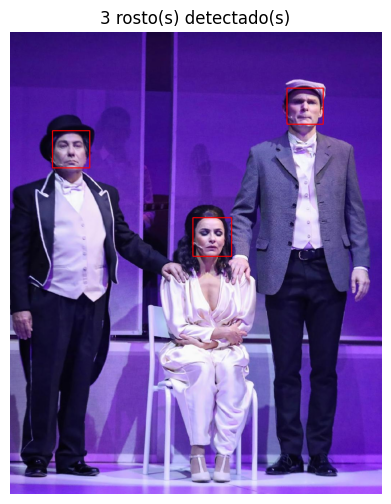

In [3]:
# -----------------------------
# 🧪 Exemplo de uso
# -----------------------------
detect_faces_image(
    r"imagem1.jpg"
)

---

## 📘 Parâmetros Importantes do Método `detectMultiScale`

| Parâmetro | Descrição | Valor Típico |
|------------|------------|--------------|
| `scaleFactor` | Controla o quanto a imagem é reduzida em cada escala. Valores menores detectam rostos de tamanhos diferentes, mas aumentam o tempo de execução. | `1.1` a `1.3` |
| `minNeighbors` | Número mínimo de vizinhos que uma região candidata precisa ter para ser considerada rosto. Valores maiores reduzem falsos positivos. | `3` a `6` |
| `minSize` | Tamanho mínimo da janela de detecção. Útil para ignorar rostos muito pequenos. | `(30, 30)` |

---

## 🧭 Boas Práticas

- Utilize imagens com **boa iluminação** e **rosto frontal**.
- Ajuste `scaleFactor` e `minNeighbors` conforme o tamanho e distância dos rostos.
- Para vídeos ou webcam, use `cv2.VideoCapture()` em um loop.
- Combine com redes neurais modernas (ex: MTCNN ou YOLOv8-face) para resultados mais robustos.

---

### 🎯 Conclusão

Com apenas algumas linhas de código, conseguimos criar um sistema funcional de **detecção de rostos**.  
Essa é uma das portas de entrada mais acessíveis para o mundo da **Visão Computacional**, permitindo explorar desde simples aplicações de imagem até sistemas inteligentes de análise visual.

### Identificação de rostos por striming

In [4]:

# Carrega o Haarcascade para detecção de faces
# face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Inicializa a câmera (0 = câmera padrão do laptop)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise IOError("Não foi possível abrir a câmera")

# Define o tempo total de captura (em segundos)
total_time = 120  # 2 minutos
start_time = time.time()

while True:
    # Checa se o tempo total passou
    if time.time() - start_time > total_time:
        break

    ret, frame = cap.read()
    if not ret:
        break

    # Converte para escala de cinza
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detecta faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    # Desenha retângulos nas faces detectadas
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Mostra o vídeo
    cv2.imshow('Detecção de Faces', frame)

    # Sai ao pressionar 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Libera a câmera e fecha as janelas
cap.release()
cv2.destroyAllWindows()

### Reconhecimento Facial

In [7]:
# --- Carrega modelo e labels ---
recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.read("modelo_lbph.yml")
with open("labels.pkl", "rb") as f:
    labels = pickle.load(f)

# --- Inicializa câmera ---
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError("❌ Não foi possível abrir a câmera.")

print("🎥 Pressione 'q' para sair.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        roi = gray[y:y+h, x:x+w]
        label_id, confidence = recognizer.predict(roi)
        if confidence < 70:  # menor valor = maior confiança
            name = labels[label_id]
            color = (0, 255, 0)
            winsound.Beep(1000, 200)  # beep 1kHz por 200ms
        else:
            name = "Desconhecido"
            color = (0, 0, 255)

        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
        cv2.putText(frame, f"{name} ({int(confidence)})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    cv2.imshow('Reconhecimento Facial', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


🎥 Pressione 'q' para sair.
